In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import yaml



In [2]:
config_path = Path("../data/configs/template.yaml")
with open(config_path) as f:
    config = yaml.safe_load(f)

In [3]:
BASE_DIR = Path.cwd()
path_to_file = BASE_DIR / "../outputs/prefactor_seperate_test/calibration_results.csv"
path_to_file = path_to_file.resolve()



#path_to_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb/calibration_run_prefactor_test_overnight/calibration_results.csv"
df = pd.read_csv(path_to_file)

CALIBRATION_PARAMS = config['calibration_parameters']
param_config = CALIBRATION_PARAMS
n_best = 6

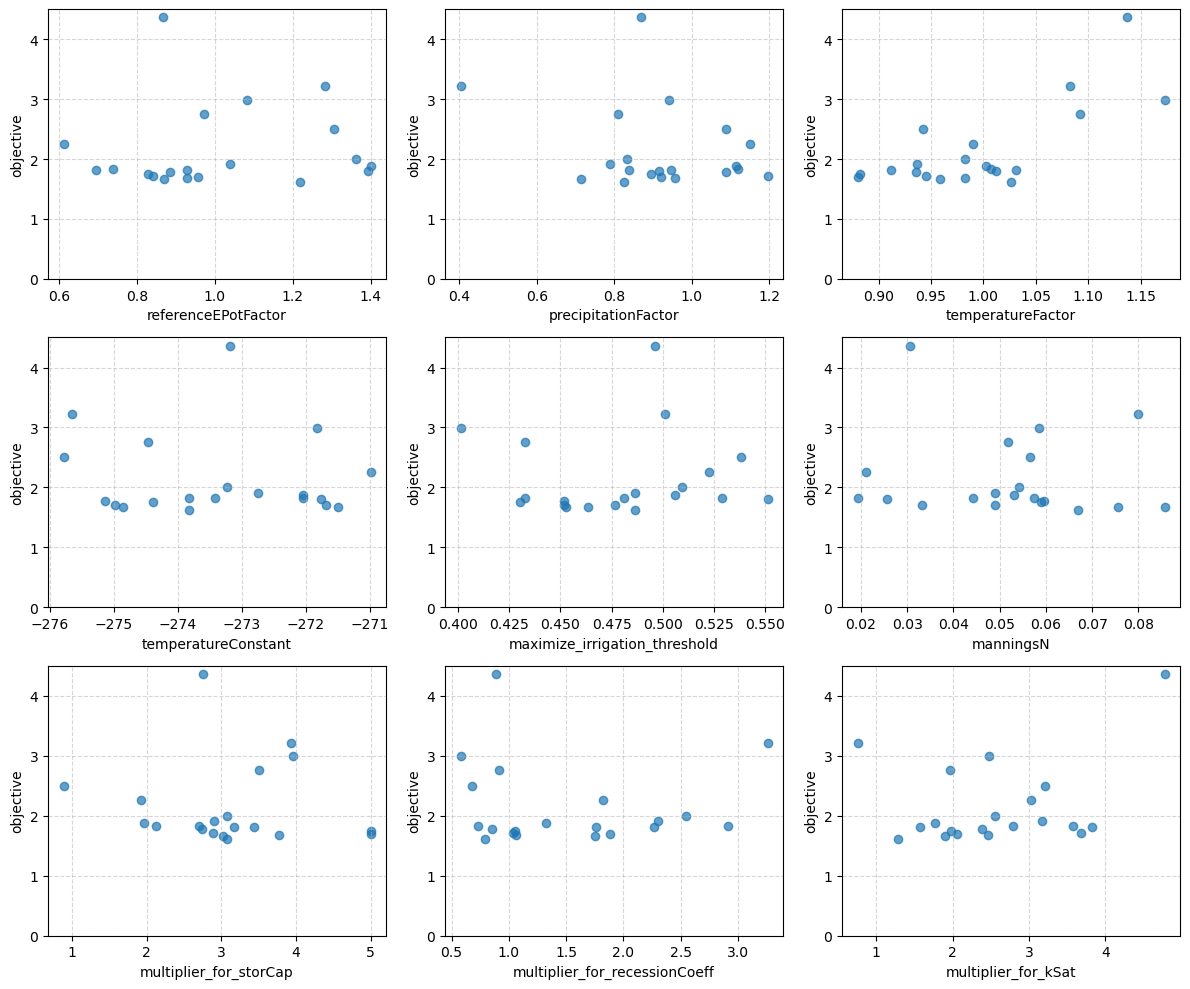

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12,10))
axes = axes.flatten()

for i, p in enumerate(param_config):
    axes[i].scatter(df[p], df["objective_value"], alpha=0.7)
    axes[i].set_xlabel(p)
    axes[i].set_ylabel("objective")
    axes[i].grid(linestyle="--", alpha=0.5)
    axes[i].set_ylim(bottom=0)

for j in range(len(param_config), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

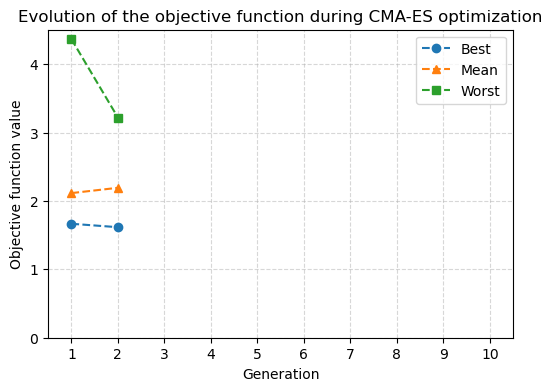

In [5]:
popsize = config["optimizer"]["popsize"]

df["generation"] = df.index // popsize

best_per_gen = df.groupby("generation")["objective_value"].min()
mean_per_gen = df.groupby("generation")["objective_value"].mean()
worst_per_gen = df.groupby("generation")["objective_value"].max()

plt.figure(figsize=(6,4))
plt.plot(best_per_gen.index+1, best_per_gen.values, linestyle="--", marker="o", label ="Best")
plt.plot(mean_per_gen.index+1, mean_per_gen.values, linestyle="--", marker="^", label="Mean")
plt.plot(worst_per_gen.index+1, worst_per_gen.values, linestyle="--", marker="s", label="Worst")

#x = list(range(1, len(best_per_gen)+1))
x = list(range(1, 11))

plt.xticks(ticks=x, labels=x)

plt.xlabel("Generation")
plt.ylabel("Objective function value")
plt.title("Evolution of the objective function during CMA-ES optimization")
plt.legend()
plt.ylim(bottom = 0)
plt.xlim(left=1-0.5, right=10.5)
plt.grid(linestyle="--", alpha=0.5)

plt.show()

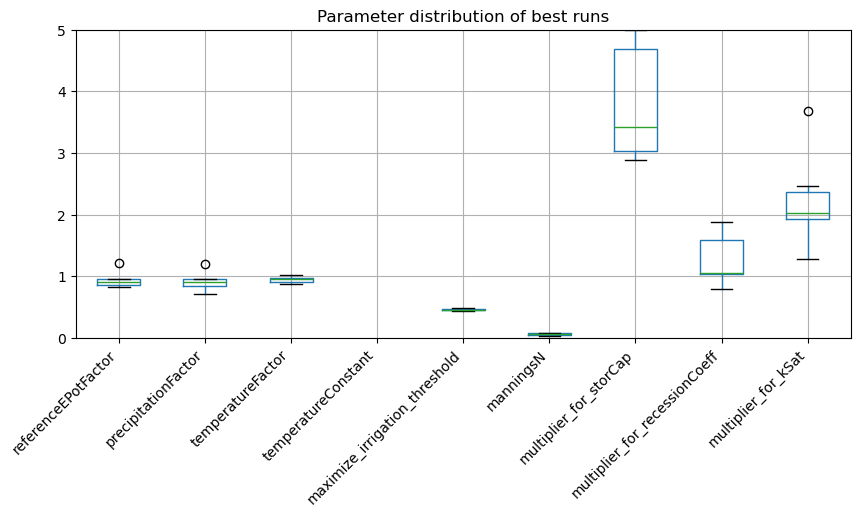

In [6]:
params = [p for p in param_config.keys() if p in df.columns]
best = df.nsmallest(n_best, "objective_value")

best[params].boxplot(figsize=(10,4))

plt.xticks(
    ticks=range(1, len(params) + 1),
    labels=params,
    rotation=45,
    ha="right",
)

plt.title("Parameter distribution of best runs")
plt.ylim(0,5)
plt.show()

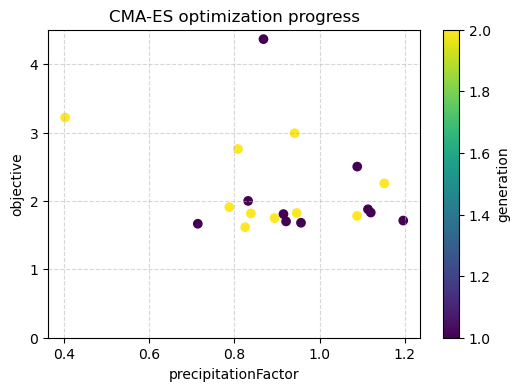

In [7]:
plt.figure(figsize=(6,4))

sc = plt.scatter(
    df["precipitationFactor"],
    df["objective_value"],
    c=df["generation"]+1,
)

plt.colorbar(sc, label="generation")
plt.xlabel("precipitationFactor")
plt.ylabel("objective")
plt.grid(linestyle="--", alpha=0.5)
plt.ylim(bottom=0)
#plt.xlim(0.8, 1.2)

plt.title("CMA-ES optimization progress")

plt.show()

In [8]:
# create scaled dataframe
df_scaled = df.copy()


for param, cfg in param_config.items():
    if param not in df.columns:
        continue
    lower, upper = cfg["bounds"]
    df_scaled[f"{param}_scaled"] = (df[param] - lower) / (upper - lower)

df_scaled.head()

,run_tag,timestamp,objective_value,referenceEPotFactor,precipitationFactor,temperatureFactor,temperatureConstant,maximize_irrigation_threshold,manningsN,multiplier_for_storCap,...,generation,referenceEPotFactor_scaled,precipitationFactor_scaled,temperatureFactor_scaled,temperatureConstant_scaled,maximize_irrigation_threshold_scaled,manningsN_scaled,multiplier_for_storCap_scaled,multiplier_for_recessionCoeff_scaled,multiplier_for_kSat_scaled
0,c61baa6f,2026-03-24 17:05:44,2.000249,1.362720,0.832493,0.982493,-273.230247,0.509408,0.054201,3.082053,...,0,0.575146,0.393175,0.456232,0.489969,0.547042,0.517903,0.573790,0.454373,0.455627
1,756f1502,2026-03-24 17:05:44,1.680703,0.927765,0.956547,0.982847,-274.848963,0.463439,0.085654,3.767062,...,0,0.285176,0.505951,0.457119,0.287630,0.317197,0.848987,0.726014,0.125513,0.436226
2,f2b6987a,2026-03-24 17:05:44,2.502185,1.305853,1.088446,0.942453,-275.783116,0.538458,0.056655,0.885581,...,0,0.537236,0.625860,0.356132,0.170861,0.692290,0.543732,0.085685,0.040240,0.601256
3,c6ef7c22,2026-03-24 17:05:44,1.666350,0.870854,0.714453,0.958497,-271.491201,0.452479,0.075602,3.026144,...,0,0.247236,0.285867,0.396244,0.707350,0.262393,0.743177,0.561365,0.277966,0.312451
4,db9362bc,2026-03-24 17:05:44,1.713187,0.841781,1.196381,0.944790,-274.984817,0.476882,0.033267,2.894014,...,0,0.227854,0.723983,0.361974,0.270648,0.384408,0.297544,0.532003,0.120043,0.706812


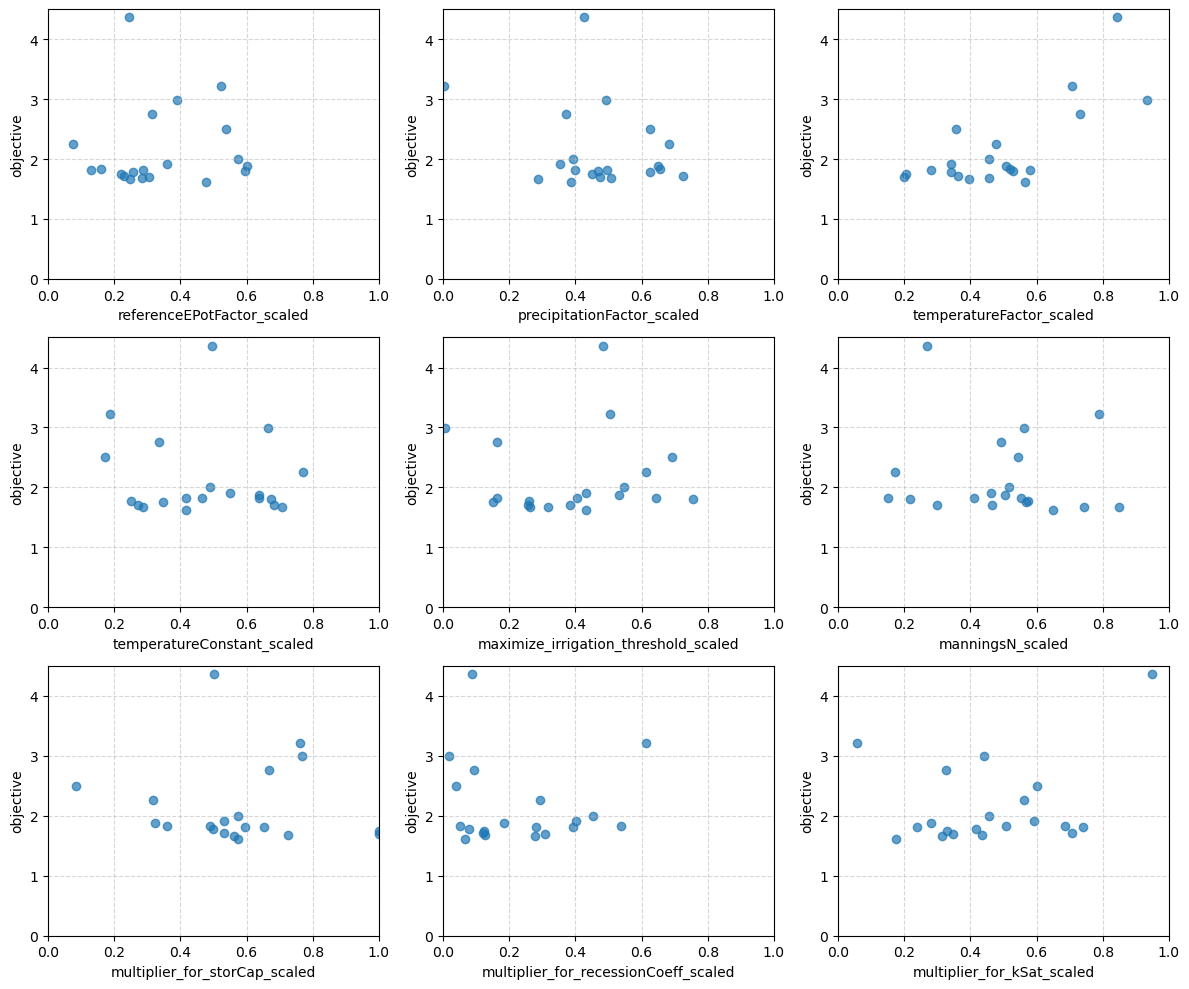

In [9]:

scaled_params = [p + "_scaled" for p in param_config.keys()]

fig, axes = plt.subplots(3,3, figsize=(12,10))
axes = axes.flatten()

for i, p in enumerate(scaled_params):
    axes[i].scatter(df_scaled[p], df_scaled["objective_value"], alpha=0.7)
    axes[i].set_xlabel(p)
    axes[i].set_ylabel("objective")
    axes[i].grid(linestyle="--", alpha=0.5)
    axes[i].set_xlim(0,1)
    axes[i].set_ylim(bottom=0)

for j in range(len(scaled_params), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

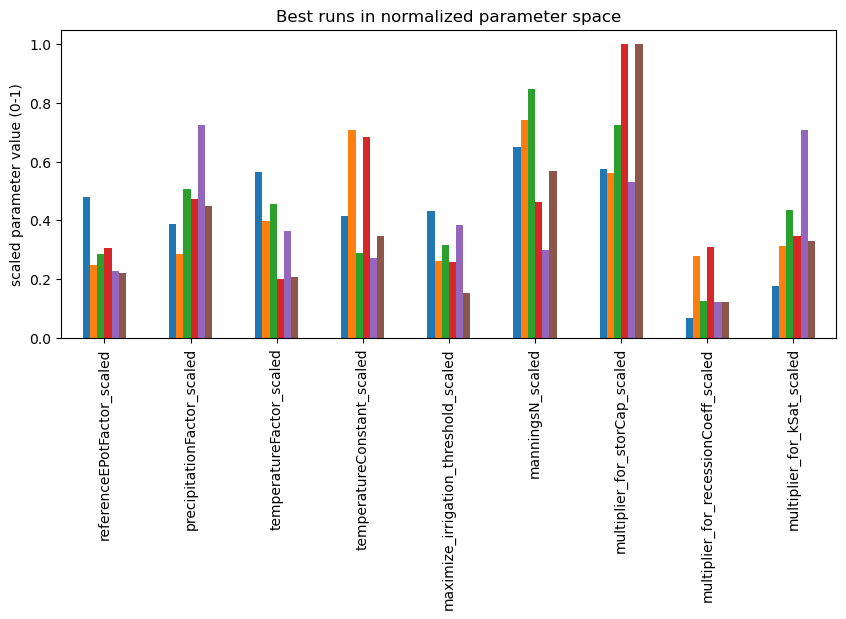

In [10]:

best = df_scaled.nsmallest(n_best, "objective_value")

best[[p + "_scaled" for p in param_config]].T.plot(
    kind="bar",
    legend=False,
    figsize=(10,4)
)

plt.ylabel("scaled parameter value (0-1)")
plt.title("Best runs in normalized parameter space")
plt.show()

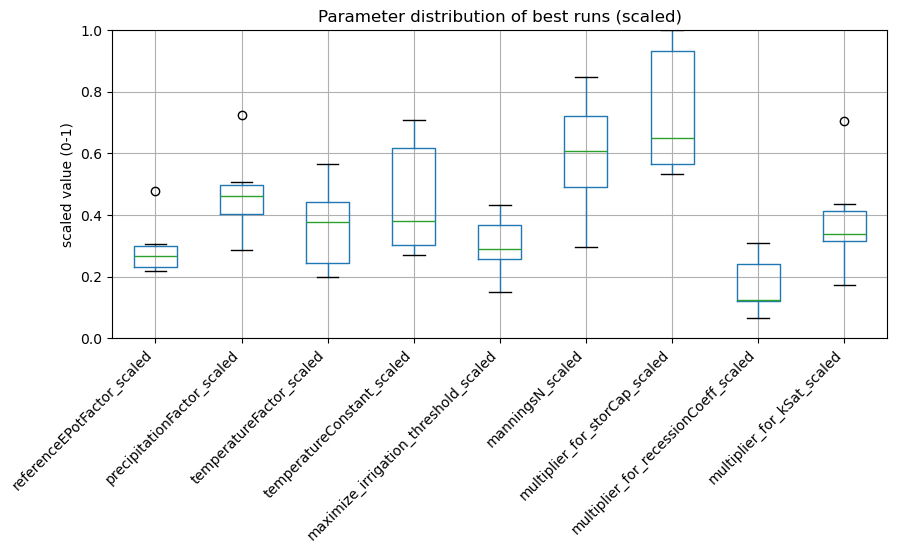

In [11]:
best = df_scaled.nsmallest(n_best, "objective_value")

scaled_params = [p + "_scaled" for p in param_config]

best[scaled_params].boxplot(figsize=(10,4))

plt.xticks(
    ticks=range(1, len(scaled_params) + 1),
    labels=scaled_params,
    rotation=45,
    ha="right",
)
plt.ylim(0, 1)

plt.ylabel("scaled value (0-1)")
plt.title("Parameter distribution of best runs (scaled)")
plt.show()

In [12]:
# # Select only good runs (important!)
df_good = df[df["objective_value"] <= 3]

# corrs = {}

# for p in param_config:
#     corrs[p] = df_good[p].corr(df_good["objective_value"])

# # Sort by absolute importance
# corrs = pd.Series(corrs).sort_values(key=lambda x: abs(x), ascending=False)

# print(corrs)

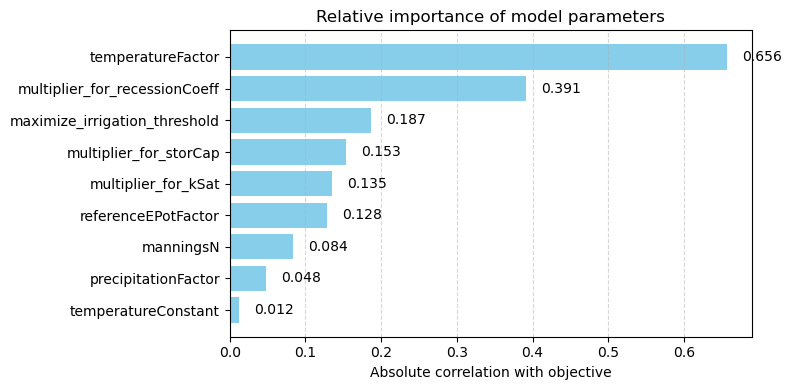

In [13]:
log_params = {
    "multiplier_for_kSat",
    "multiplier_for_recessionCoeff",
    # add all multipliers applied in log-space
}

# example in correlation loop:


corrs = {}
for p in param_config:
    if p in df_good.columns:
        x = np.log10(df_good[p]) if p in log_params else df_good[p]
        corrs[p] = x.corr(df_good["objective_value"])
        #corrs[p] = df_good[p].corr(df_good["objective_value"])

corrs = pd.Series(corrs).dropna().sort_values(key=lambda x: x.abs(), ascending=False)

# params and absolute correlations
params = corrs.index.tolist()
values = corrs.abs().tolist()



plt.figure(figsize=(8,4))
plt.barh(params, values, color="skyblue")
plt.xlabel("Absolute correlation with objective")
plt.title("Relative importance of model parameters")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)

for i, v in enumerate(values):
    plt.text(v + 0.02, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

In [14]:
corrs

temperatureFactor                0.656289
multiplier_for_recessionCoeff   -0.391013
maximize_irrigation_threshold   -0.186899
multiplier_for_storCap          -0.153176
multiplier_for_kSat              0.135031
referenceEPotFactor              0.128045
manningsN                       -0.083884
precipitationFactor              0.048169
temperatureConstant              0.011674
dtype: float64

Model comparison by parameter
- R2 columns are in-sample
- CV RMSE columns are cross-validated (lower is better)


,parameter,transform,linear_r2,piecewise_r2,smooth_r2,linear_rmse,piecewise_rmse,smooth_rmse,linear_cv_rmse,piecewise_cv_rmse,smooth_cv_rmse,best_model_cv,best_cv_rmse,cv_gain_vs_linear,smooth_kind,piecewise_break_transformed,piecewise_break_original
0,maximize_irrigation_threshold,none,0.0349,0.5598,0.5827,0.3774,0.2549,0.2482,0.4539,0.3860,0.3475,smooth,0.3475,0.1064,smoothing_spline,0.4525,0.4525
1,multiplier_for_recessionCoeff,log10,0.1529,0.5127,0.4574,0.3536,0.2682,0.2830,0.3996,0.3172,0.3364,piecewise,0.3172,0.0824,smoothing_spline,-0.1003,0.7939
2,temperatureFactor,none,0.4307,0.6529,0.5789,0.2898,0.2263,0.2493,0.3156,0.3180,0.9877,linear,0.3156,-0.0024,smoothing_spline,1.0264,1.0264
3,referenceEPotFactor,none,0.0164,0.0922,0.2482,0.3810,0.3660,0.3331,0.4200,0.4971,0.4280,linear,0.4200,-0.0080,smoothing_spline,1.3059,1.3059
4,manningsN,none,0.0070,0.1443,0.0979,0.3828,0.3554,0.3649,0.4121,0.4248,0.5213,linear,0.4121,-0.0127,smoothing_spline,0.0567,0.0567
5,temperatureConstant,none,0.0001,0.1077,0.0862,0.3841,0.3629,0.3672,0.4106,0.4563,0.5332,linear,0.4106,-0.0457,smoothing_spline,-274.8490,-274.8490
6,multiplier_for_kSat,log10,0.0182,0.1627,0.1390,0.3806,0.3515,0.3564,0.3956,0.4486,0.4946,linear,0.3956,-0.0530,smoothing_spline,0.5059,3.2057
7,multiplier_for_storCap,none,0.0235,0.1327,0.2805,0.3796,0.3577,0.3258,0.4158,0.4735,0.9403,linear,0.4158,-0.0577,smoothing_spline,2.1192,2.1192
8,precipitationFactor,none,0.0023,0.0286,0.0220,0.3837,0.3786,0.3799,0.4022,1.2381,0.8222,linear,0.4022,-0.4200,smoothing_spline,1.0884,1.0884


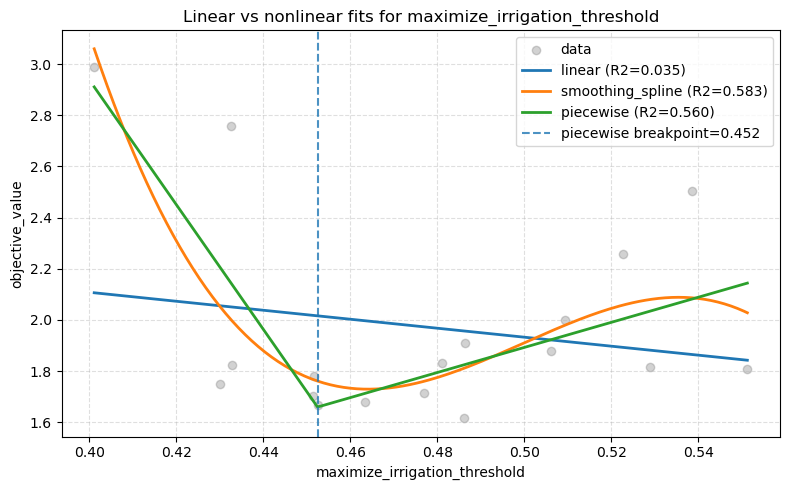

In [15]:
# Compare linear vs nonlinear relationships per parameter.
# Uses both in-sample R2 and cross-validated RMSE (more robust for model comparison).
analysis_df = df_good.copy() if "df_good" in globals() else df.copy()
target_col = "objective_value"
params = [p for p in param_config.keys() if p in analysis_df.columns]
log_params_local = log_params if "log_params" in globals() else set()

def _r2_rmse(y_true, y_pred):
    residuals = y_true - y_pred
    sse = float(np.sum(residuals ** 2))
    sst = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = np.nan if np.isclose(sst, 0.0) else 1.0 - (sse / sst)
    rmse = float(np.sqrt(np.mean(residuals ** 2)))
    return r2, rmse

def fit_linear_model(x, y):
    X = np.column_stack([np.ones_like(x), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return {"coef": coef}

def predict_linear(model, x):
    X = np.column_stack([np.ones_like(x), x])
    return X @ model["coef"]

def fit_piecewise_model(x, y, min_fraction=0.15, max_candidates=35):
    n = len(x)
    if n < 12:
        return None

    x_sorted = np.sort(x)
    lo = x_sorted[int(np.floor(min_fraction * (n - 1)))]
    hi = x_sorted[int(np.ceil((1.0 - min_fraction) * (n - 1)))]
    candidate_breaks = np.unique(x[(x > lo) & (x < hi)])

    if len(candidate_breaks) == 0:
        return None

    if len(candidate_breaks) > max_candidates:
        idx = np.linspace(0, len(candidate_breaks) - 1, max_candidates, dtype=int)
        candidate_breaks = candidate_breaks[idx]

    best = None
    for bp in candidate_breaks:
        hinge = np.maximum(0.0, x - bp)
        X = np.column_stack([np.ones_like(x), x, hinge])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ coef
        r2, _ = _r2_rmse(y, y_hat)

        if (best is None) or (r2 > best["r2"]):
            best = {
                "coef": coef,
                "breakpoint": float(bp),
                "r2": r2,
            }

    return best

def predict_piecewise(model, x):
    if model is None:
        return np.full_like(x, np.nan, dtype=float)
    hinge = np.maximum(0.0, x - model["breakpoint"])
    X = np.column_stack([np.ones_like(x), x, hinge])
    return X @ model["coef"]

def fit_smooth_model(x, y):
    x_sorted = np.sort(x)
    y_sorted = y[np.argsort(x)]

    try:
        from scipy.interpolate import UnivariateSpline

        # Larger smoothing factor reduces overfitting in small samples.
        smooth_strength = len(x_sorted) * np.var(y_sorted) * 1.0
        spline = UnivariateSpline(x_sorted, y_sorted, k=3, s=smooth_strength)
        return {"kind": "smoothing_spline", "spline": spline}
    except Exception:
        max_deg = min(3, len(np.unique(x_sorted)) - 1)
        deg = max(1, max_deg)
        coeffs = np.polyfit(x_sorted, y_sorted, deg=deg)
        return {"kind": f"poly_deg{deg}", "coeffs": coeffs}

def predict_smooth(model, x):
    if model["kind"] == "smoothing_spline":
        return model["spline"](x)
    return np.polyval(model["coeffs"], x)

def cv_rmse(x, y, fit_fn, pred_fn, n_splits=5, min_train=10, seed=42):
    n = len(x)
    if n < (min_train + 2):
        return np.nan

    n_splits = min(n_splits, n)
    if n_splits < 2:
        return np.nan

    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    folds = np.array_split(indices, n_splits)

    sq_errors = []
    for test_idx in folds:
        test_idx = np.array(test_idx, dtype=int)
        train_idx = np.setdiff1d(indices, test_idx, assume_unique=False)

        if len(train_idx) < min_train or len(test_idx) == 0:
            continue

        model = fit_fn(x[train_idx], y[train_idx])
        if model is None:
            continue

        y_pred = pred_fn(model, x[test_idx])
        valid = np.isfinite(y_pred)
        if not np.any(valid):
            continue

        err = y[test_idx][valid] - y_pred[valid]
        sq_errors.extend((err ** 2).tolist())

    if len(sq_errors) == 0:
        return np.nan

    return float(np.sqrt(np.mean(sq_errors)))

results = []
fit_store = {}

for p in params:
    x_raw = analysis_df[p].to_numpy(dtype=float)
    y_raw = analysis_df[target_col].to_numpy(dtype=float)

    finite = np.isfinite(x_raw) & np.isfinite(y_raw)
    x = x_raw[finite]
    y = y_raw[finite]

    if len(x) < 12:
        continue

    transform = "none"
    if p in log_params_local:
        positive = x > 0
        x = np.log10(x[positive])
        y = y[positive]
        transform = "log10"

    if len(x) < 12:
        continue

    linear_model = fit_linear_model(x, y)
    y_linear = predict_linear(linear_model, x)
    linear_r2, linear_rmse = _r2_rmse(y, y_linear)

    piecewise_model = fit_piecewise_model(x, y)
    y_piecewise = predict_piecewise(piecewise_model, x)
    piecewise_r2, piecewise_rmse = _r2_rmse(y, y_piecewise) if piecewise_model is not None else (np.nan, np.nan)

    smooth_model = fit_smooth_model(x, y)
    y_smooth = predict_smooth(smooth_model, x)
    smooth_r2, smooth_rmse = _r2_rmse(y, y_smooth)

    linear_cv = cv_rmse(x, y, fit_linear_model, predict_linear)
    piecewise_cv = cv_rmse(x, y, fit_piecewise_model, predict_piecewise)
    smooth_cv = cv_rmse(x, y, fit_smooth_model, predict_smooth)

    cv_scores = {
        "linear": linear_cv,
        "piecewise": piecewise_cv,
        "smooth": smooth_cv,
    }
    valid_cv = {k: v for k, v in cv_scores.items() if np.isfinite(v)}
    best_model_cv = min(valid_cv, key=valid_cv.get) if valid_cv else "n/a"
    best_cv_rmse = valid_cv[best_model_cv] if valid_cv else np.nan

    non_linear_valid = [v for k, v in valid_cv.items() if k != "linear"]
    best_non_linear_cv = min(non_linear_valid) if len(non_linear_valid) > 0 else np.nan
    cv_gain_vs_linear = linear_cv - best_non_linear_cv if np.isfinite(linear_cv) and np.isfinite(best_non_linear_cv) else np.nan

    bp_transformed = np.nan
    bp_original = np.nan
    if piecewise_model is not None:
        bp_transformed = piecewise_model["breakpoint"]
        bp_original = 10 ** bp_transformed if transform == "log10" else bp_transformed

    results.append(
        {
            "parameter": p,
            "transform": transform,
            "linear_r2": linear_r2,
            "piecewise_r2": piecewise_r2,
            "smooth_r2": smooth_r2,
            "linear_rmse": linear_rmse,
            "piecewise_rmse": piecewise_rmse,
            "smooth_rmse": smooth_rmse,
            "linear_cv_rmse": linear_cv,
            "piecewise_cv_rmse": piecewise_cv,
            "smooth_cv_rmse": smooth_cv,
            "best_model_cv": best_model_cv,
            "best_cv_rmse": best_cv_rmse,
            "cv_gain_vs_linear": cv_gain_vs_linear,
            "smooth_kind": smooth_model["kind"],
            "piecewise_break_transformed": bp_transformed,
            "piecewise_break_original": bp_original,
        }
    )

    fit_store[p] = {
        "transform": transform,
        "x": x,
        "y": y,
        "linear": linear_model,
        "piecewise": piecewise_model,
        "smooth": smooth_model,
        "stats": {
            "linear_r2": linear_r2,
            "piecewise_r2": piecewise_r2,
            "smooth_r2": smooth_r2,
        },
    }

comparison = (
    pd.DataFrame(results)
    .sort_values(["cv_gain_vs_linear", "best_cv_rmse"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Model comparison by parameter")
print("- R2 columns are in-sample")
print("- CV RMSE columns are cross-validated (lower is better)")
display(comparison.round(4))

if comparison.empty:
    print("No parameters had enough valid data points to fit.")
else:
    # Plot the parameter with strongest nonlinear improvement in CV RMSE.
    param_to_plot = comparison.loc[0, "parameter"]  # change this to inspect another parameter
    fit_data = fit_store[param_to_plot]

    x_min, x_max = np.min(fit_data["x"]), np.max(fit_data["x"])
    x_grid = np.linspace(x_min, x_max, 200)

    plt.figure(figsize=(8, 5))
    plt.scatter(fit_data["x"], fit_data["y"], alpha=0.35, label="data", color="0.5")

    y_linear_grid = predict_linear(fit_data["linear"], x_grid)
    plt.plot(
        x_grid,
        y_linear_grid,
        linewidth=2,
        label=f"linear (R2={fit_data['stats']['linear_r2']:.3f})",
    )

    y_smooth_grid = predict_smooth(fit_data["smooth"], x_grid)
    smooth_label = f"{fit_data['smooth']['kind']} (R2={fit_data['stats']['smooth_r2']:.3f})"
    plt.plot(x_grid, y_smooth_grid, linewidth=2, label=smooth_label)

    piecewise_model = fit_data["piecewise"]
    if piecewise_model is not None:
        y_piecewise_grid = predict_piecewise(piecewise_model, x_grid)
        plt.plot(
            x_grid,
            y_piecewise_grid,
            linewidth=2,
            label=f"piecewise (R2={fit_data['stats']['piecewise_r2']:.3f})",
        )
        plt.axvline(
            piecewise_model["breakpoint"],
            linestyle="--",
            alpha=0.8,
            label=f"piecewise breakpoint={piecewise_model['breakpoint']:.3g}",
        )

    x_label = f"log10({param_to_plot})" if fit_data["transform"] == "log10" else param_to_plot
    plt.xlabel(x_label)
    plt.ylabel(target_col)
    plt.title(f"Linear vs nonlinear fits for {param_to_plot}")
    plt.grid(linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

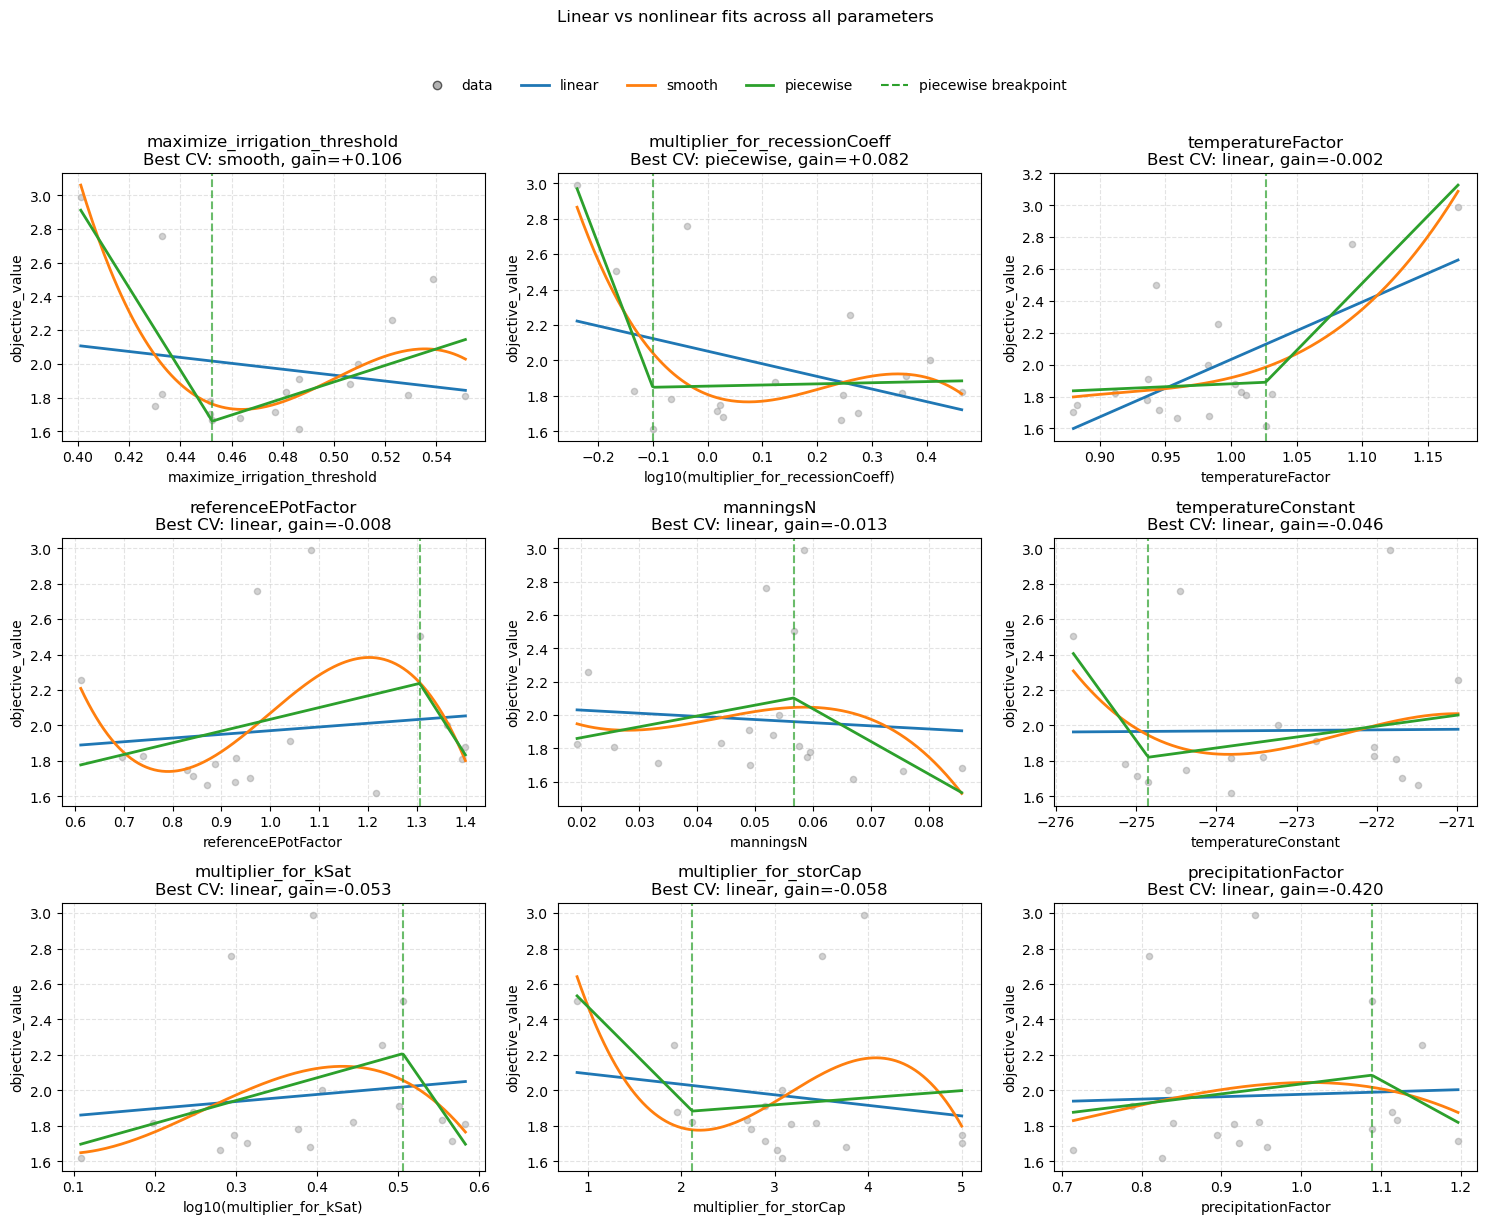

In [16]:
# Small-multiples view: compare all parameter fits in one figure.
if "comparison" not in globals() or "fit_store" not in globals():
    raise RuntimeError("Run the previous model-comparison cell first.")

plot_params = comparison["parameter"].tolist()
if len(plot_params) == 0:
    raise RuntimeError("No parameters available to plot.")

n_cols = 3
n_rows = int(np.ceil(len(plot_params) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows), squeeze=False)
axes = axes.ravel()

for i, p in enumerate(plot_params):
    ax = axes[i]
    row = comparison.loc[comparison["parameter"] == p].iloc[0]
    fit_data = fit_store[p]

    x = fit_data["x"]
    y = fit_data["y"]
    x_grid = np.linspace(np.min(x), np.max(x), 200)

    ax.scatter(x, y, alpha=0.35, s=20, color="0.5")

    ax.plot(x_grid, predict_linear(fit_data["linear"], x_grid), color="#1f77b4", linewidth=2)
    ax.plot(x_grid, predict_smooth(fit_data["smooth"], x_grid), color="#ff7f0e", linewidth=2)

    piecewise_model = fit_data["piecewise"]
    if piecewise_model is not None:
        ax.plot(x_grid, predict_piecewise(piecewise_model, x_grid), color="#2ca02c", linewidth=2)
        ax.axvline(piecewise_model["breakpoint"], color="#2ca02c", linestyle="--", alpha=0.7)

    best_cv = row["best_model_cv"]
    gain = row["cv_gain_vs_linear"]
    gain_txt = "nan" if not np.isfinite(gain) else f"{gain:+.3f}"

    ax.set_title(f"{p}\nBest CV: {best_cv}, gain={gain_txt}")
    x_label = f"log10({p})" if fit_data["transform"] == "log10" else p
    ax.set_xlabel(x_label)
    ax.set_ylabel(target_col)
    ax.grid(linestyle="--", alpha=0.35)

for j in range(len(plot_params), len(axes)):
    axes[j].axis("off")

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="0.5", markersize=6, alpha=0.6, label="data"),
    Line2D([0], [0], color="#1f77b4", linewidth=2, label="linear"),
    Line2D([0], [0], color="#ff7f0e", linewidth=2, label="smooth"),
    Line2D([0], [0], color="#2ca02c", linewidth=2, label="piecewise"),
    Line2D([0], [0], color="#2ca02c", linewidth=1.5, linestyle="--", label="piecewise breakpoint"),
]

fig.legend(handles=legend_handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Linear vs nonlinear fits across all parameters", y=1.07)
plt.tight_layout()
plt.show()

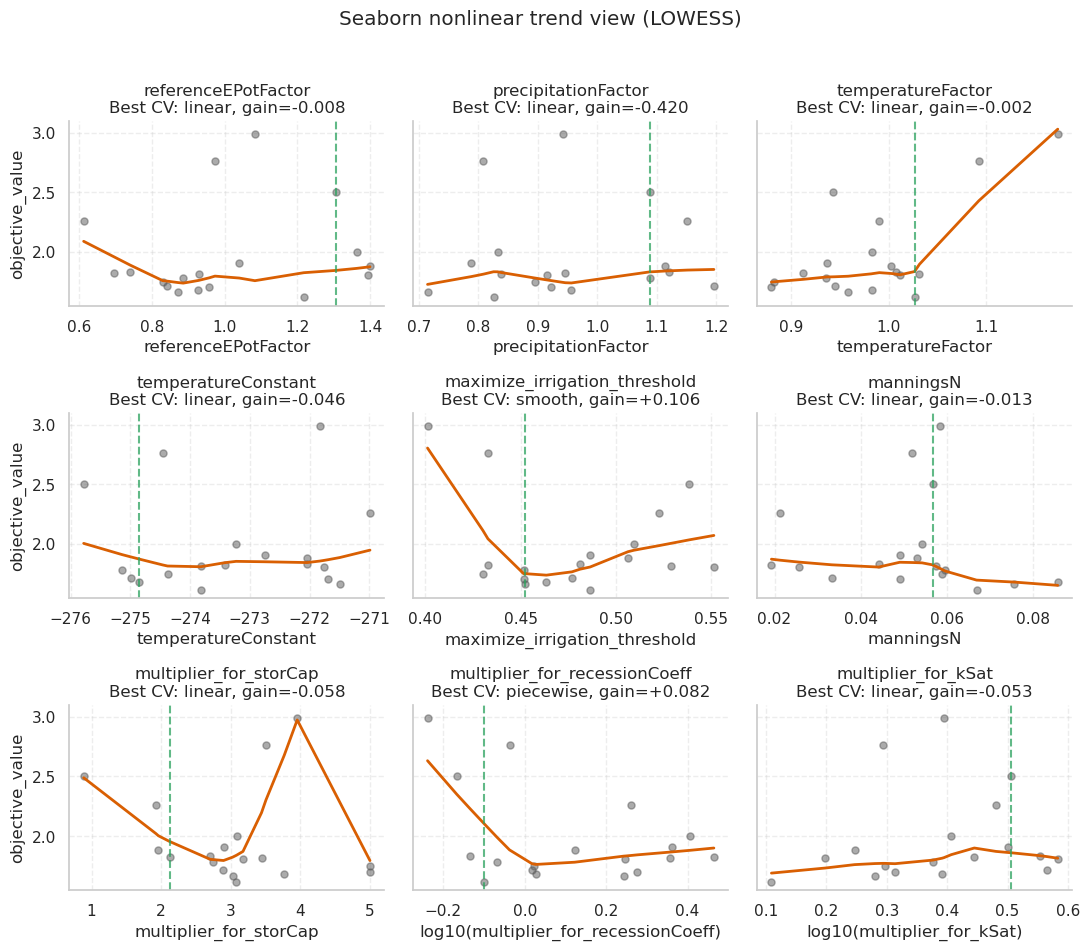

In [17]:
# Seaborn small-multiples: nonlinear trend per parameter.
# LOWESS is used when statsmodels is available; otherwise falls back to quadratic fit.
try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        "Seaborn is not installed in this kernel. Install seaborn and rerun this cell."
    ) from exc

analysis_df = df_good.copy() if "df_good" in globals() else df.copy()
target_col = "objective_value"
params = [p for p in param_config.keys() if p in analysis_df.columns]
log_params_local = log_params if "log_params" in globals() else set()

rows = []
x_label_map = {}

for p in params:
    x = analysis_df[p].to_numpy(dtype=float)
    y = analysis_df[target_col].to_numpy(dtype=float)

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if p in log_params_local:
        positive = x > 0
        x = np.log10(x[positive])
        y = y[positive]
        x_label_map[p] = f"log10({p})"
    else:
        x_label_map[p] = p

    if len(x) < 4:
        continue

    rows.append(pd.DataFrame({"parameter": p, "x": x, target_col: y}))

if len(rows) == 0:
    raise RuntimeError("No valid data available for Seaborn plotting.")

plot_df = pd.concat(rows, ignore_index=True)

use_lowess = True
try:
    import statsmodels.api as _sm  # noqa: F401
except Exception:
    use_lowess = False

sns.set_theme(style="whitegrid")
g = sns.FacetGrid(
    plot_df,
    col="parameter",
    col_wrap=3,
    sharex=False,
    sharey=True,
    height=3.1,
    aspect=1.2,
)

common_kws = {
    "scatter_kws": {"alpha": 0.5, "s": 26, "color": "0.35"},
    "line_kws": {"color": "#d95f02", "lw": 2},
}

if use_lowess:
    g.map_dataframe(
        sns.regplot,
        x="x",
        y=target_col,
        lowess=True,
        ci=None,
        **common_kws,
    )
    fit_label = "LOWESS"
else:
    g.map_dataframe(
        sns.regplot,
        x="x",
        y=target_col,
        order=2,
        ci=None,
        **common_kws,
    )
    fit_label = "quadratic"

if "comparison" in globals():
    cmp = comparison.set_index("parameter")
    for ax, p in zip(g.axes.flat, g.col_names):
        if p in cmp.index:
            best_cv = cmp.loc[p, "best_model_cv"]
            gain = cmp.loc[p, "cv_gain_vs_linear"]
            gain_txt = "nan" if not np.isfinite(gain) else f"{gain:+.3f}"
            ax.set_title(f"{p}\nBest CV: {best_cv}, gain={gain_txt}")

            if "piecewise_break_transformed" in cmp.columns:
                bp = cmp.loc[p, "piecewise_break_transformed"]
                if np.isfinite(bp):
                    ax.axvline(bp, linestyle="--", color="#2ca25f", alpha=0.75, lw=1.5)
        else:
            ax.set_title(p)
else:
    for ax, p in zip(g.axes.flat, g.col_names):
        ax.set_title(p)

for ax, p in zip(g.axes.flat, g.col_names):
    ax.set_xlabel(x_label_map.get(p, p))
    ax.set_ylabel(target_col)
    ax.grid(linestyle="--", alpha=0.35)

g.fig.suptitle(f"Seaborn nonlinear trend view ({fit_label})", y=1.02)
plt.tight_layout()
plt.show()

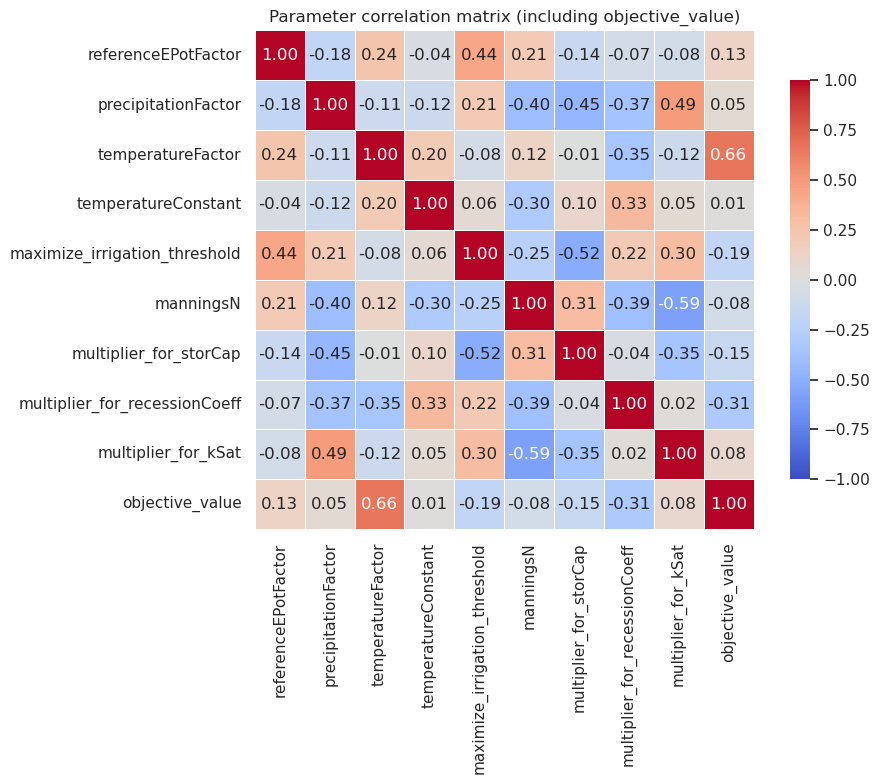

In [18]:
# Correlation heatmap: parameter-to-parameter and parameter-to-objective correlations.
try:
    import seaborn as sns
except ImportError:
    raise ImportError("Seaborn is required for this cell.")

analysis_df = df_good.copy() if "df_good" in globals() else df.copy()
params = [p for p in param_config.keys() if p in analysis_df.columns]

corr_matrix = analysis_df[params + ["objective_value"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
)
plt.title("Parameter correlation matrix (including objective_value)")
plt.tight_layout()
plt.show()


Showing top 6 parameters by correlation magnitude: ['temperatureFactor', 'multiplier_for_recessionCoeff', 'maximize_irrigation_threshold', 'multiplier_for_storCap', 'referenceEPotFactor', 'manningsN']


/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/seaborn/axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become

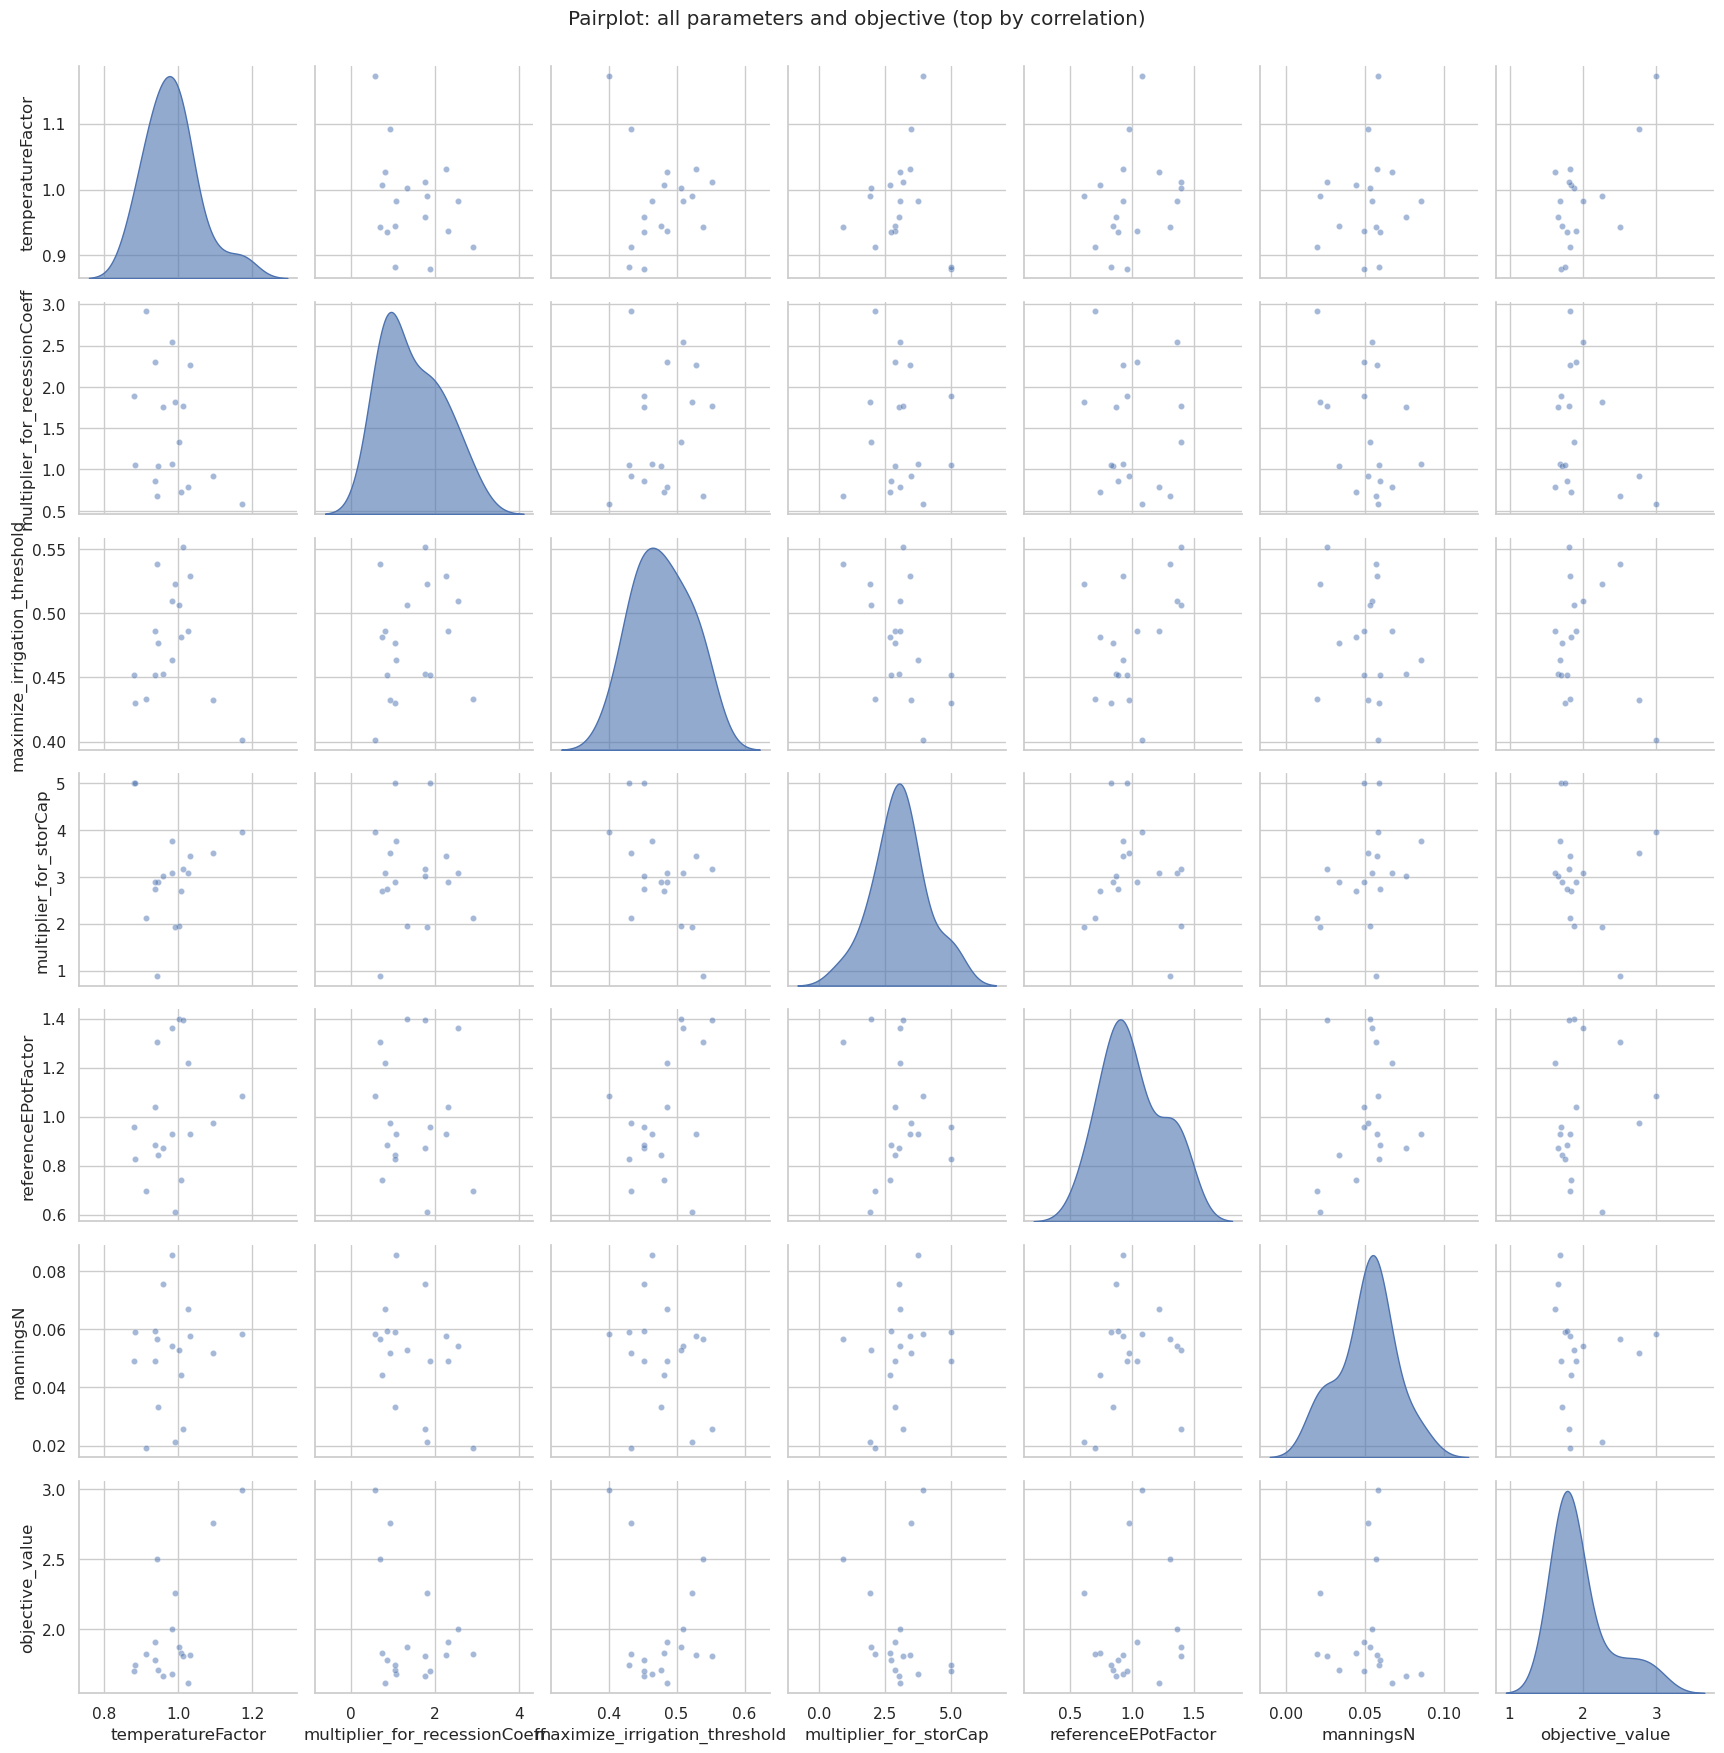

In [19]:
# Pairplot: scatterplot matrix across all parameters and objective.
# Shows multivariate patterns; can be large but very informative.
try:
    import seaborn as sns
except ImportError:
    raise ImportError("Seaborn is required for this cell.")

analysis_df = df_good.copy() if "df_good" in globals() else df.copy()
params = [p for p in param_config.keys() if p in analysis_df.columns]

# Select a subset of the most important parameters if there are many.
# Use the correlation magnitude ranking to pick the top ones.
if len(params) > 6:
    corr_with_obj = analysis_df[params].corrwith(analysis_df["objective_value"]).abs().sort_values(ascending=False)
    selected_params = corr_with_obj.head(6).index.tolist()
    print(f"Showing top 6 parameters by correlation magnitude: {selected_params}")
else:
    selected_params = params

plot_data = analysis_df[selected_params + ["objective_value"]].copy()

g = sns.pairplot(
    plot_data,
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20},
    diag_kws={"shade": True, "alpha": 0.6},
)

g.fig.suptitle("Pairplot: all parameters and objective (top by correlation)", y=1.001)
plt.tight_layout()
plt.show()
